In [1]:
import os
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft

In [2]:
dataset_path = "UrbanSound8K"

In [3]:
metadata = pd.read_csv(
    os.path.join(dataset_path,
                 "metadata",
                 "UrbanSound8K.csv")
)

metadata.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [4]:
print("Total Samples:", len(metadata))
print("Number of Classes:", metadata['class'].nunique())

print("\nClasses:")
print(metadata['class'].unique())

Total Samples: 8732
Number of Classes: 10

Classes:
<StringArray>
[        'dog_bark', 'children_playing',         'car_horn',
  'air_conditioner',     'street_music',         'gun_shot',
            'siren',    'engine_idling',       'jackhammer',
         'drilling']
Length: 10, dtype: str


In [5]:
sample = metadata.iloc[0]

audio_path = os.path.join(
    dataset_path,
    "audio",
    f"fold{sample.fold}",
    sample.slice_file_name
)

print(audio_path)

UrbanSound8K/audio/fold5/100032-3-0-0.wav


In [6]:
y, sr = librosa.load(
    audio_path,
    sr=None
)

print("Sample Rate:", sr)
print("Audio Length:", len(y))

/opt/anaconda3/envs/quantization/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sample Rate: 44100
Audio Length: 14004


In [7]:
from IPython.display import Audio

Audio(y, rate=sr)

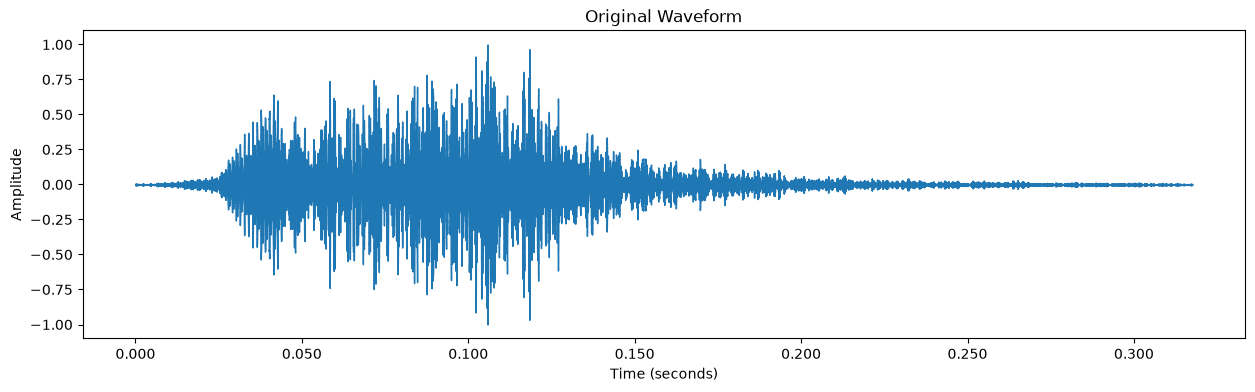

In [8]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(15,4))

librosa.display.waveshow(y, sr=sr)

plt.title("Original Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

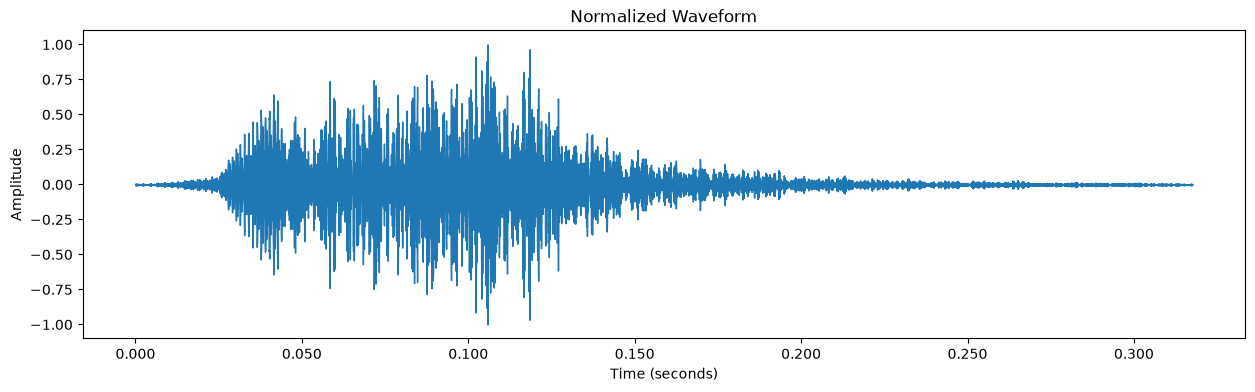

In [9]:
y_normalized = librosa.util.normalize(y)

plt.figure(figsize=(15,4))

librosa.display.waveshow(y_normalized, sr=sr)

plt.title("Normalized Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

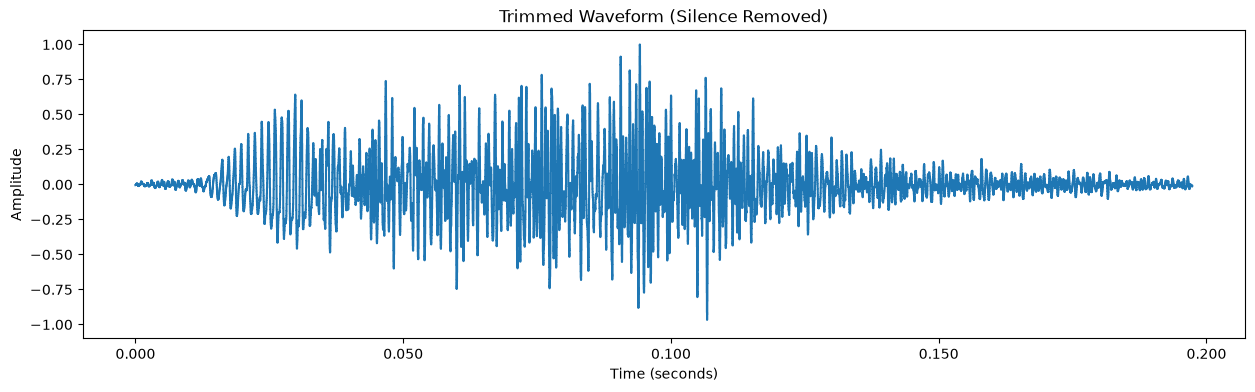

In [10]:
y_trimmed, _ = librosa.effects.trim(y_normalized, top_db=20)

plt.figure(figsize=(15,4))

librosa.display.waveshow(y_trimmed, sr=sr)

plt.title("Trimmed Waveform (Silence Removed)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

In [11]:
target_sr = 16000

y_resampled = librosa.resample(
    y_trimmed,
    orig_sr=sr,
    target_sr=target_sr
)

print("Original Sample Rate:", sr)
print("Resampled Sample Rate:", target_sr)

Original Sample Rate: 44100
Resampled Sample Rate: 16000


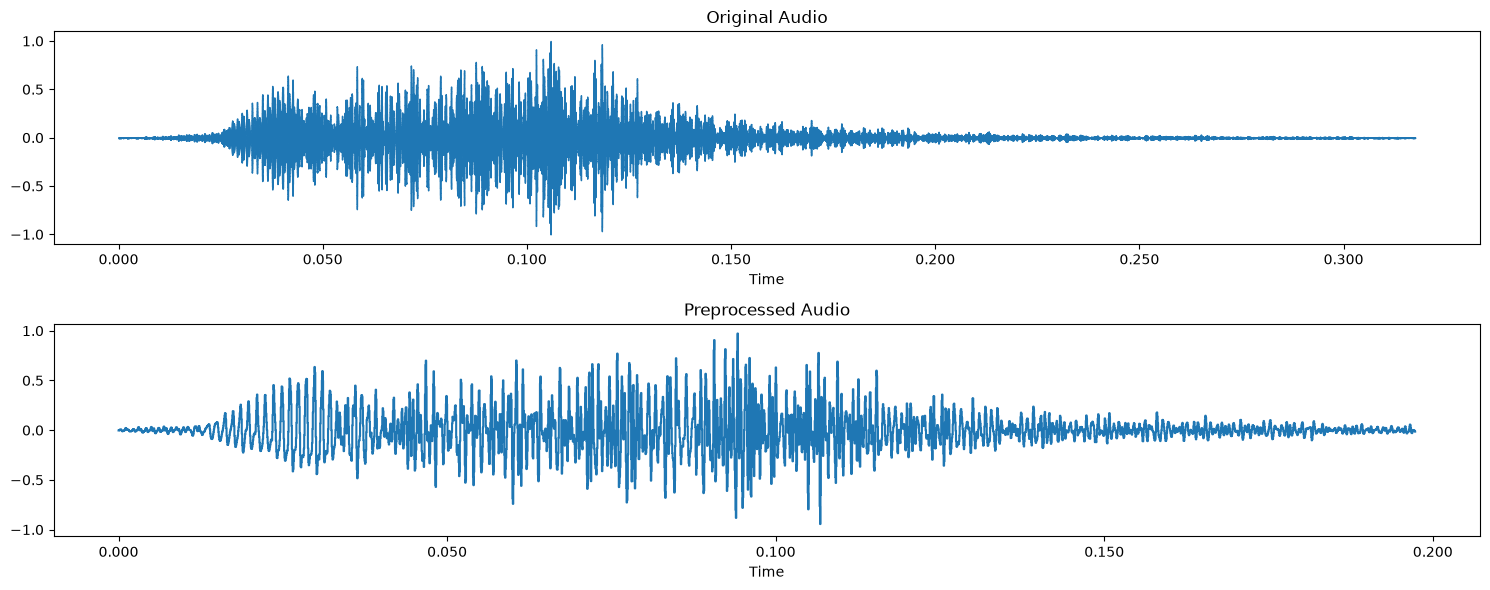

In [12]:
fig, ax = plt.subplots(2, 1, figsize=(15,6))

librosa.display.waveshow(y, sr=sr, ax=ax[0])
ax[0].set_title("Original Audio")

librosa.display.waveshow(y_resampled, sr=target_sr, ax=ax[1])
ax[1].set_title("Preprocessed Audio")

plt.tight_layout()
plt.show()

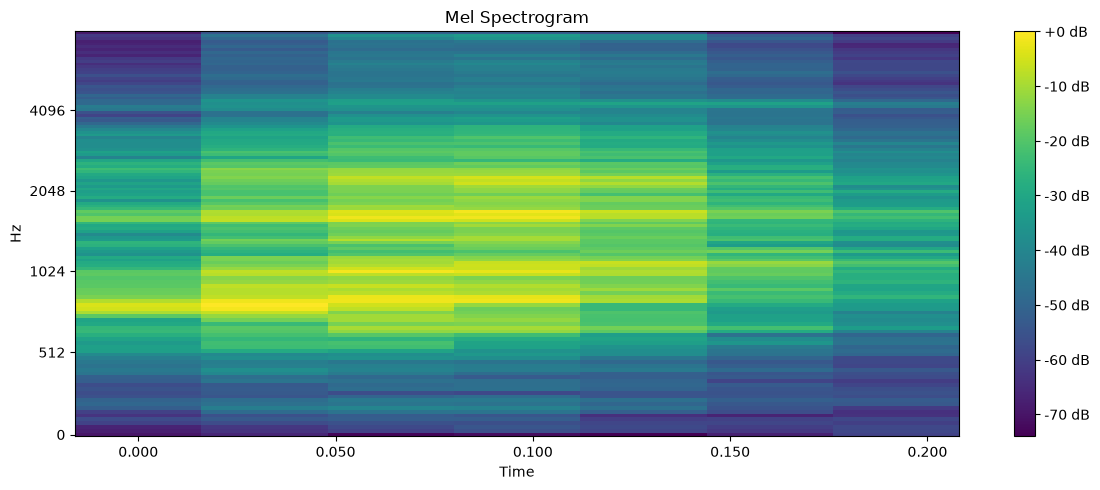

In [13]:
# Create Mel Spectrogram
mel_spec = librosa.feature.melspectrogram(
    y=y_resampled,
    sr=target_sr,
    n_mels=128,
    n_fft=2048,
    hop_length=512
)

# Convert to Decibels
mel_db = librosa.power_to_db(mel_spec, ref=np.max)

# Plot
plt.figure(figsize=(12,5))

librosa.display.specshow(
    mel_db,
    sr=target_sr,
    x_axis='time',
    y_axis='mel',
    cmap='viridis'
)

plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")
plt.tight_layout()
plt.show()

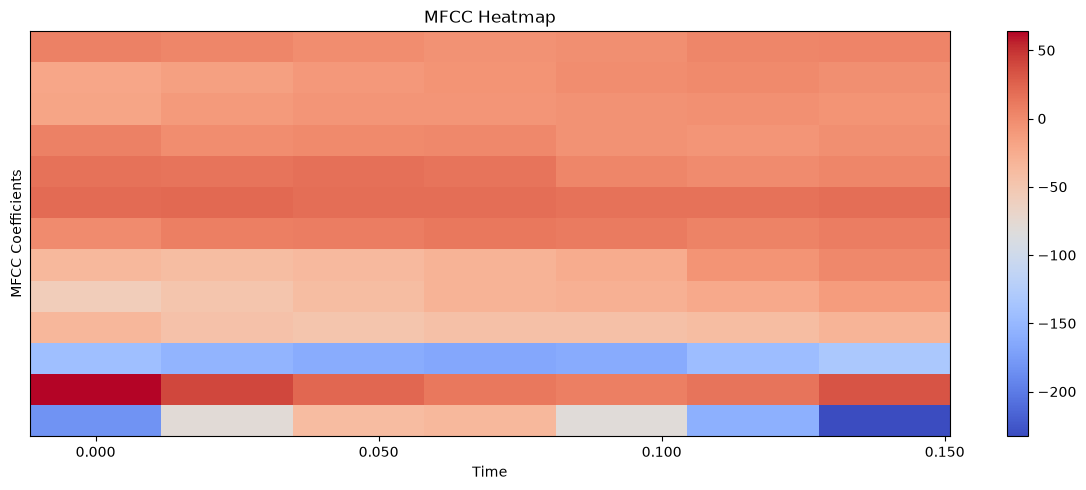

In [14]:
mfcc = librosa.feature.mfcc(
    y=y_resampled,
    sr=target_sr,
    n_mfcc=13
)

plt.figure(figsize=(12,5))

librosa.display.specshow(
    mfcc,
    x_axis='time',
    cmap='coolwarm'
)

plt.colorbar()
plt.title("MFCC Heatmap")
plt.ylabel("MFCC Coefficients")
plt.tight_layout()

plt.show()

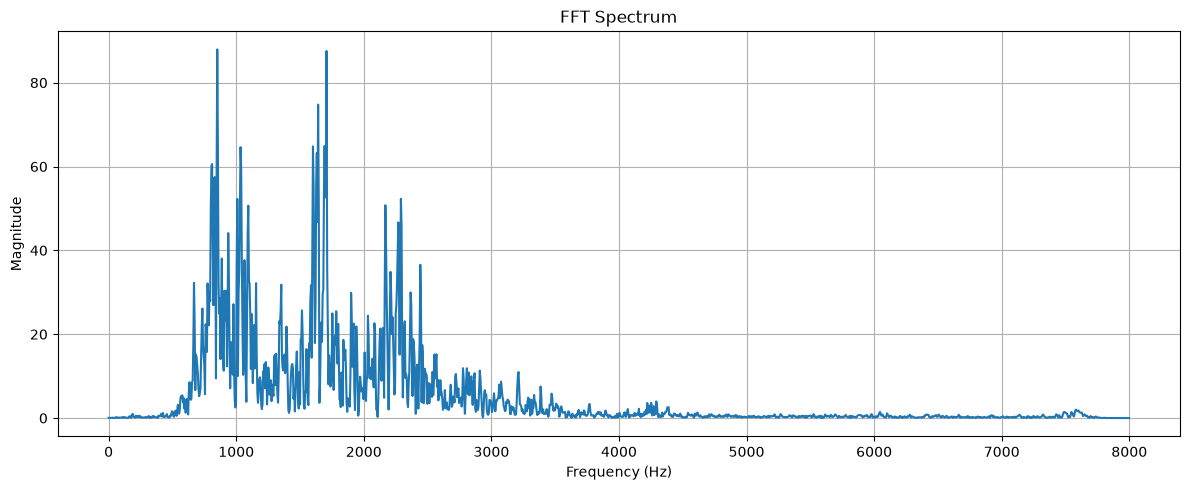

In [15]:
from scipy.fft import fft

N = len(y_resampled)

yf = np.abs(fft(y_resampled))
xf = np.linspace(0, target_sr, N)

plt.figure(figsize=(12,5))

plt.plot(xf[:N//2], yf[:N//2])

plt.title("FFT Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)

plt.tight_layout()
plt.show()

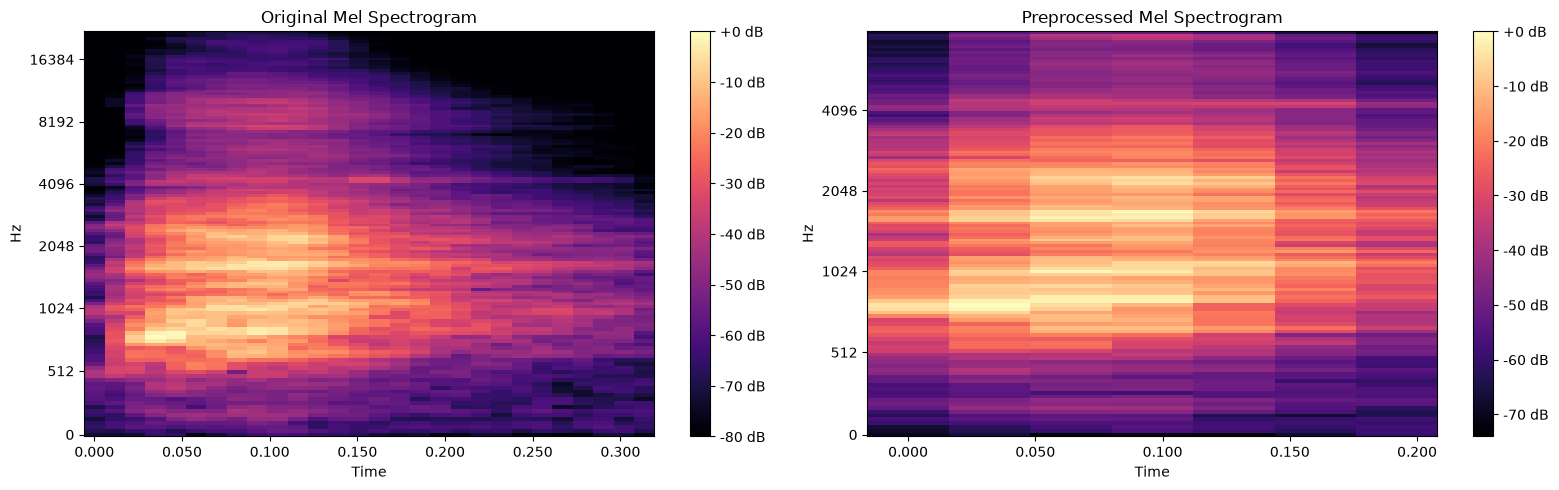

In [16]:
# Original
mel_original = librosa.feature.melspectrogram(
    y=y,
    sr=sr
)

mel_original_db = librosa.power_to_db(
    mel_original,
    ref=np.max
)

# Processed
mel_processed = librosa.feature.melspectrogram(
    y=y_resampled,
    sr=target_sr
)

mel_processed_db = librosa.power_to_db(
    mel_processed,
    ref=np.max
)

fig, ax = plt.subplots(1,2, figsize=(16,5))

img1 = librosa.display.specshow(
    mel_original_db,
    sr=sr,
    x_axis='time',
    y_axis='mel',
    ax=ax[0]
)

ax[0].set_title("Original Mel Spectrogram")

img2 = librosa.display.specshow(
    mel_processed_db,
    sr=target_sr,
    x_axis='time',
    y_axis='mel',
    ax=ax[1]
)

ax[1].set_title("Preprocessed Mel Spectrogram")

plt.colorbar(img1, ax=ax[0], format="%+2.0f dB")
plt.colorbar(img2, ax=ax[1], format="%+2.0f dB")

plt.tight_layout()
plt.show()

In [17]:
from IPython.display import display, Audio

print("Original Audio")
display(Audio(y, rate=sr))

print("Preprocessed Audio")
display(Audio(y_resampled, rate=target_sr))

Original Audio


Preprocessed Audio


## Observations

1. The audio was successfully loaded from the UrbanSound8K dataset.

2. Normalization scaled the audio amplitudes to a consistent range without changing the waveform shape.

3. Silence trimming removed unnecessary silent regions from the beginning and end of the recording.

4. The audio was resampled to 16 kHz, producing a standardized sampling rate suitable for audio processing tasks.

5. The Mel spectrogram clearly shows how the sound energy is distributed across time and frequency.

6. The MFCC heatmap captures compact spectral features commonly used in speech and audio classification.

7. The FFT spectrum illustrates the dominant frequency components present in the signal.

8. Comparing the original and preprocessed representations shows that preprocessing improves consistency while preserving the important characteristics of the audio signal.

## Conclusion

In this experiment, an audio sample from the UrbanSound8K dataset was preprocessed using normalization, silence removal, and resampling. The waveform, Mel spectrogram, MFCC heatmap, and FFT spectrum were generated to visualize the audio signal. The comparison between the original and preprocessed audio demonstrates that preprocessing enhances the consistency and quality of the signal while retaining its essential information. These preprocessing steps provide a strong foundation for subsequent audio analysis and machine learning tasks.